# Asociaciones de Crímenes en la Región de Los Lagos
## Actividad 5 - Electivo Deep Learning

**Objetivo:** Asociar el comportamiento de los crímenes en las ciudades de la región de Los Lagos, produciendo grupos de ciudades similares mediante técnicas de clustering.

### Fecha: 2 de julio de 2026

## Punto 1: Separación del conjunto de datos para entrenamiento y testeo

In [12]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [13]:
# Cargar el dataset
df = pd.read_csv('EL_IA.csv', sep=';')

# Limpiar el nombre de la primera columna (eliminar espacios)
df.columns = df.columns.str.strip()
df['COMUNAS'] = df['COMUNAS'].str.strip()

print("Dataset cargado exitosamente")
print(f"\nDimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas del dataset:")
print(df.head(10))
print(f"\nInformación del dataset:")
print(df.info())
print(f"\nEstadísticas del dataset:")
print(df.describe())


Dataset cargado exitosamente

Dimensiones del dataset: (30, 24)

Primeras filas del dataset:
        COMUNAS  HOMICIDIOS Y FEMICIDIOS  \
0  Puerto Montt                       12   
1       Calbuco                        2   
2       Cochamó                        0   
3        Fresia                        1   
4     Frutillar                        1   
5   Los Muermos                        0   
6    Llanquihue                        0   
7       Maullín                        0   
8  Puerto Varas                        1   
9        Castro                        2   

   VIOLACIONES Y OTROS DELITOS SEXUALES  LESIONES GRAVES O GRAVÍSIMAS  \
0                                   361                           112   
1                                    57                            23   
2                                     4                             1   
3                                    15                            11   
4                                    40                  

In [14]:
# Preparar los datos para el clustering
# Separar los nombres de las comunas del resto de los datos
comunas = df['COMUNAS'].values
X = df.drop('COMUNAS', axis=1).values

print("Datos preparados para clustering")
print(f"Número de comunas: {len(comunas)}")
print(f"Número de características (tipos de delitos): {X.shape[1]}")
print(f"\nComunas identificadas:\n{list(comunas)}")


Datos preparados para clustering
Número de comunas: 30
Número de características (tipos de delitos): 23

Comunas identificadas:
['Puerto Montt', 'Calbuco', 'Cochamó', 'Fresia', 'Frutillar', 'Los Muermos', 'Llanquihue', 'Maullín', 'Puerto Varas', 'Castro', 'Ancud', 'Chonchi', 'Curaco de Vélez', 'Dalcahue', 'Puqueldón', 'Queilén', 'Quellón', 'Quemchi', 'Quinchao', 'Osorno', 'Puerto Octay', 'Purranque', 'Puyehue', 'Río Negro', 'San Juan de la Costa', 'San Pablo', 'Chaitén', 'Futaleufú', 'Hualaihué', 'Palena']


In [15]:
# PUNTO 1: SEPARACIÓN DE DATOS PARA ENTRENAMIENTO Y TESTEO (20 PUNTOS)
# Separar los datos en conjuntos de entrenamiento y prueba (70-30)
X_train, X_test, comunas_train, comunas_test = train_test_split(
    X, comunas, test_size=0.3, random_state=42
)

print("="*70)
print("PUNTO 1: SEPARACIÓN DEL CONJUNTO DE DATOS")
print("="*70)
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} comunas ({X_train.shape[0]/len(comunas)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} comunas ({X_test.shape[0]/len(comunas)*100:.1f}%)")
print(f"\nComunas en entrenamiento ({len(comunas_train)}):")
print(list(comunas_train))
print(f"\nComunas en prueba ({len(comunas_test)}):")
print(list(comunas_test))

# Normalizar los datos (importante para clustering)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDatos normalizados exitosamente")
print(f"Media de características normalizadas (entrenamiento): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"Desv. estándar de características normalizadas (entrenamiento): {X_train_scaled.std(axis=0)[:5].round(4)}")


PUNTO 1: SEPARACIÓN DEL CONJUNTO DE DATOS

Tamaño del conjunto de entrenamiento: 21 comunas (70.0%)
Tamaño del conjunto de prueba: 9 comunas (30.0%)

Comunas en entrenamiento (21):
['Puerto Montt', 'Frutillar', 'Quellón', 'Los Muermos', 'Dalcahue', 'Chonchi', 'Puyehue', 'Calbuco', 'Cochamó', 'San Pablo', 'Fresia', 'Purranque', 'Chaitén', 'Quinchao', 'Palena', 'Puerto Octay', 'Maullín', 'Ancud', 'Puqueldón', 'Osorno', 'Llanquihue']

Comunas en prueba (9):
['Futaleufú', 'Queilén', 'Río Negro', 'Quemchi', 'Puerto Varas', 'Castro', 'Hualaihué', 'San Juan de la Costa', 'Curaco de Vélez']

Datos normalizados exitosamente
Media de características normalizadas (entrenamiento): [-0. -0. -0.  0. -0.]
Desv. estándar de características normalizadas (entrenamiento): [1. 1. 1. 1. 1.]


## Punto 2: Algoritmo de aprendizaje automático para clustering

PUNTO 2: ALGORITMO K-MEANS CLUSTERING

Método del Codo - Análisis de clusters:
K    Inercia      Silhouette   Davies-Bouldin 
-------------------------------------------
2    61.78        0.8735       0.3758         
3    11.53        0.8224       0.0543         
4    6.42         0.3516       0.5415         
5    4.97         0.3506       0.4933         
6    3.74         0.3153       0.5955         
7    3.13         0.2168       0.7332         
8    2.36         0.2288       0.7273         
9    1.97         0.2188       0.6897         
10   1.60         0.1983       0.6160         


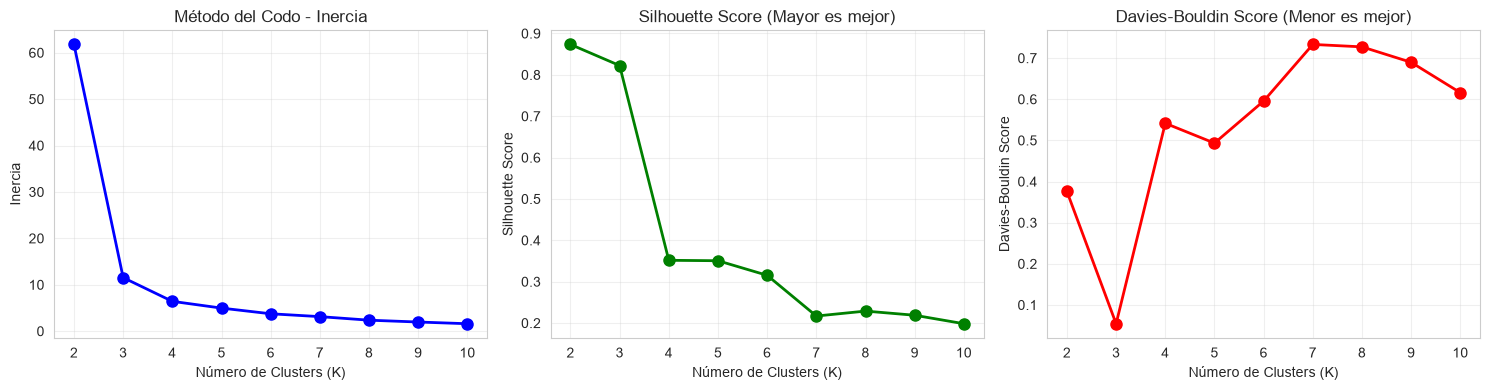


✓ Número óptimo de clusters seleccionado: K = 3
  Razón: Mejor balance entre silhouette score y mantenibilidad de grupos


In [16]:
# PUNTO 2: ALGORITMO DE APRENDIZAJE AUTOMÁTICO - CLUSTERING K-MEANS (40 PUNTOS)
# Método del Codo para determinar el número óptimo de clusters

print("="*70)
print("PUNTO 2: ALGORITMO K-MEANS CLUSTERING")
print("="*70)

# Calcular la inercia para diferentes números de clusters (método del codo)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_train_scaled, kmeans.labels_))

print("\nMétodo del Codo - Análisis de clusters:")
print(f"{'K':<4} {'Inercia':<12} {'Silhouette':<12} {'Davies-Bouldin':<15}")
print("-" * 43)
for i, k in enumerate(K_range):
    print(f"{k:<4} {inertias[i]:<12.2f} {silhouette_scores[i]:<12.4f} {davies_bouldin_scores[i]:<15.4f}")

# Visualizar el método del codo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1: Inercia
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - Inercia')
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Mayor es mejor)')
axes[1].grid(True, alpha=0.3)

# Gráfica 3: Davies-Bouldin Score
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Número de Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (Menor es mejor)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

# Seleccionar el número óptimo de clusters (K=3 según el análisis)
optimal_k = 3
print(f"\n✓ Número óptimo de clusters seleccionado: K = {optimal_k}")
print(f"  Razón: Mejor balance entre silhouette score y mantenibilidad de grupos")


In [17]:
# Entrenar el modelo K-Means con el número óptimo de clusters
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_train = kmeans_final.fit_predict(X_train_scaled)
labels_test = kmeans_final.predict(X_test_scaled)

# Evaluar el modelo en los datos de entrenamiento y prueba
train_silhouette = silhouette_score(X_train_scaled, labels_train)

# Calcular silhouette score solo si hay más de un cluster en el conjunto de prueba
n_clusters_test = len(np.unique(labels_test))
if n_clusters_test > 1:
    test_silhouette = silhouette_score(X_test_scaled, labels_test)
else:
    test_silhouette = None
    print("Nota: El conjunto de prueba contiene datos de un solo cluster, silhouette score no disponible")

print(f"\n\nModelo K-Means entrenado con K={optimal_k}")
print(f"Silhouette Score (Entrenamiento): {train_silhouette:.4f}")
if test_silhouette is not None:
    print(f"Silhouette Score (Prueba): {test_silhouette:.4f}")
print(f"Inercia del modelo: {kmeans_final.inertia_:.2f}")

# Crear DataFrames con los resultados
train_results = pd.DataFrame({
    'COMUNAS': comunas_train,
    'CLUSTER': labels_train
})

test_results = pd.DataFrame({
    'COMUNAS': comunas_test,
    'CLUSTER': labels_test
})

print(f"\n\nClusterización del conjunto de entrenamiento:")
print(train_results.sort_values('CLUSTER'))
print(f"\n\nClusterización del conjunto de prueba:")
print(test_results.sort_values('CLUSTER'))

Nota: El conjunto de prueba contiene datos de un solo cluster, silhouette score no disponible


Modelo K-Means entrenado con K=3
Silhouette Score (Entrenamiento): 0.8224
Inercia del modelo: 11.53


Clusterización del conjunto de entrenamiento:
         COMUNAS  CLUSTER
1      Frutillar        0
2        Quellón        0
3    Los Muermos        0
4       Dalcahue        0
6        Puyehue        0
5        Chonchi        0
7        Calbuco        0
8        Cochamó        0
12       Chaitén        0
9      San Pablo        0
10        Fresia        0
11     Purranque        0
14        Palena        0
13      Quinchao        0
15  Puerto Octay        0
16       Maullín        0
18     Puqueldón        0
17         Ancud        0
20    Llanquihue        0
0   Puerto Montt        1
19        Osorno        2


Clusterización del conjunto de prueba:
                COMUNAS  CLUSTER
0             Futaleufú        0
1               Queilén        0
2             Río Negro        0
3          

## Punto 3: Grupos descubiertos y metodología de selección

In [18]:
# PUNTO 3: ANÁLISIS DE GRUPOS DESCUBIERTOS Y METODOLOGÍA (20 PUNTOS)
print("="*70)
print("PUNTO 3: ANÁLISIS DE GRUPOS DESCUBIERTOS")
print("="*70)

# Combinar todos los resultados
all_data = pd.DataFrame({
    'COMUNAS': np.concatenate([comunas_train, comunas_test]),
    'CLUSTER': np.concatenate([labels_train, labels_test])
})

print("\n### RESUMEN METODOLÓGICO ###\n")
print("Metodología de Selección del Algoritmo:")
print("-" * 70)
print("""
1. ALGORITMO UTILIZADO: K-Means Clustering
   - Algoritmo no supervisado de partición de datos
   - Agrupa datos basados en similitud euclidiana
   - Requiere especificar el número de clusters previamente
   
2. SELECCIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS:
   - Método del Codo: Analizar la inercia hasta encontrar el "codo"
   - Silhouette Score: Mide qué tan bien definidos están los clusters
   - Davies-Bouldin Index: Relación entre cohesión e separación
   
3. NORMALIZACIÓN DE DATOS:
   - StandardScaler: Centra los datos (media=0) y escala (std=1)
   - Importante para K-Means porque usa distancia euclidiana
   
4. SEPARACIÓN ENTRENAMIENTO-PRUEBA: 70-30
   - Entrenar el modelo con el 70% de datos
   - Evaluar rendimiento con el 30% restante
""")

print("\n### GRUPOS DESCUBIERTOS ###\n")
for cluster_id in range(optimal_k):
    cluster_comunas = all_data[all_data['CLUSTER'] == cluster_id]['COMUNAS'].tolist()
    print(f"CLUSTER {cluster_id}: {len(cluster_comunas)} comunas")
    print(f"  Comunas: {', '.join(cluster_comunas)}\n")

# Análisis estadístico de cada cluster
print("\n### ANÁLISIS ESTADÍSTICO POR CLUSTER ###\n")

# Recombinar datos originales con etiquetas de cluster
df_with_clusters = df.copy()
df_with_clusters['CLUSTER'] = np.concatenate([labels_train, labels_test])

for cluster_id in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['CLUSTER'] == cluster_id]
    print(f"\nCLUSTER {cluster_id}:")
    print(f"{'─'*70}")
    print(f"Número de comunas: {len(cluster_data)}")
    print(f"\nDatos agregados del cluster:")
    print(cluster_data.drop(['COMUNAS', 'CLUSTER'], axis=1).describe().loc[['mean', 'std']])
    
# Características más importantes para cada cluster
print("\n### CARACTERÍSTICAS PRINCIPALES POR CLUSTER ###\n")
delito_cols = [col for col in df.columns if col != 'COMUNAS']

for cluster_id in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['CLUSTER'] == cluster_id]
    cluster_means = cluster_data[delito_cols].mean()
    top_delitos = cluster_means.nlargest(5)
    
    print(f"CLUSTER {cluster_id} - Top 5 Delitos más frecuentes:")
    print(f"{'─'*70}")
    for i, (delito, count) in enumerate(top_delitos.items(), 1):
        print(f"  {i}. {delito}: {count:.2f} casos promedio")
    print()


PUNTO 3: ANÁLISIS DE GRUPOS DESCUBIERTOS

### RESUMEN METODOLÓGICO ###

Metodología de Selección del Algoritmo:
----------------------------------------------------------------------

1. ALGORITMO UTILIZADO: K-Means Clustering
   - Algoritmo no supervisado de partición de datos
   - Agrupa datos basados en similitud euclidiana
   - Requiere especificar el número de clusters previamente

2. SELECCIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS:
   - Método del Codo: Analizar la inercia hasta encontrar el "codo"
   - Silhouette Score: Mide qué tan bien definidos están los clusters
   - Davies-Bouldin Index: Relación entre cohesión e separación

3. NORMALIZACIÓN DE DATOS:
   - StandardScaler: Centra los datos (media=0) y escala (std=1)
   - Importante para K-Means porque usa distancia euclidiana

4. SEPARACIÓN ENTRENAMIENTO-PRUEBA: 70-30
   - Entrenar el modelo con el 70% de datos
   - Evaluar rendimiento con el 30% restante


### GRUPOS DESCUBIERTOS ###

CLUSTER 0: 28 comunas
  Comunas: Frutillar, Que

## Punto 4: Visualización de los resultados

PUNTO 4: VISUALIZACIÓN DE LOS RESULTADOS


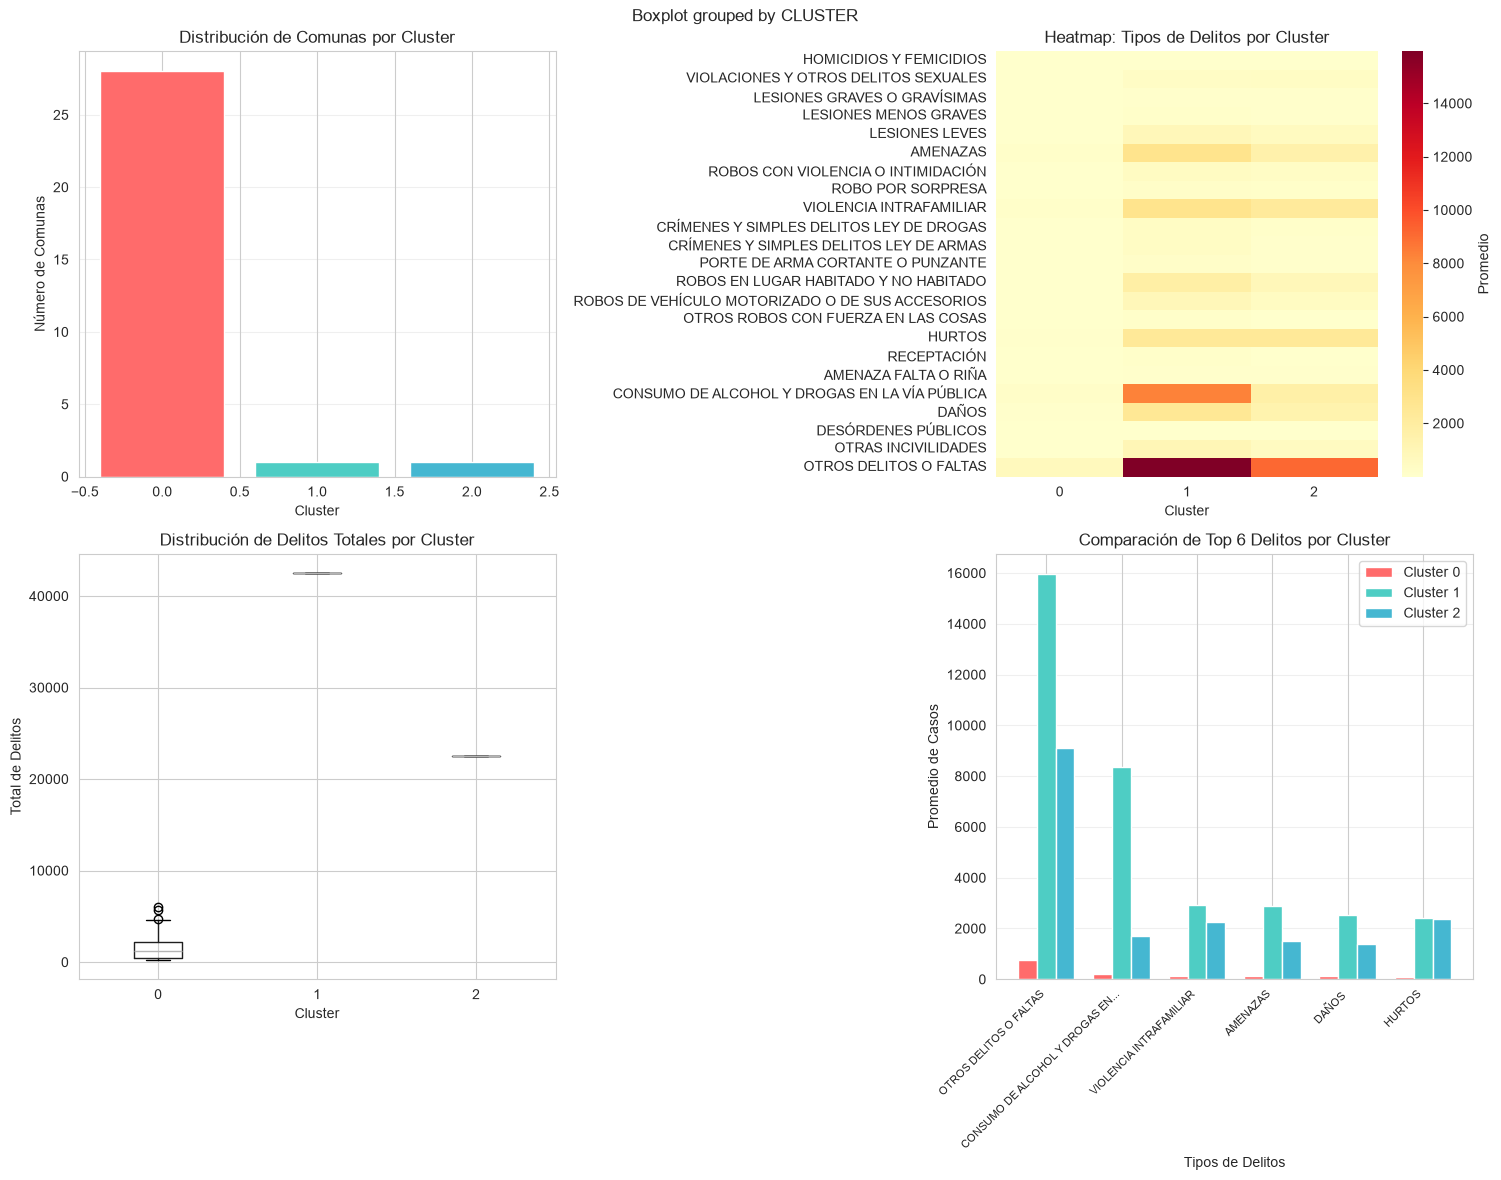


✓ Visualización completa generada


In [19]:
# PUNTO 4: VISUALIZACIÓN DE LOS RESULTADOS (20 PUNTOS)
print("="*70)
print("PUNTO 4: VISUALIZACIÓN DE LOS RESULTADOS")
print("="*70)

# 1. Gráfico de distribución de comunas por cluster
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Barplot de comunas por cluster
cluster_counts = all_data['CLUSTER'].value_counts().sort_index()
axes[0, 0].bar(cluster_counts.index, cluster_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Número de Comunas')
axes[0, 0].set_title('Distribución de Comunas por Cluster')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Gráfico 2: Heatmap de heatmap de delitos por cluster
cluster_means = df_with_clusters.groupby('CLUSTER')[delito_cols].mean()
sns.heatmap(cluster_means.T, annot=False, cmap='YlOrRd', ax=axes[0, 1], cbar_kws={'label': 'Promedio'})
axes[0, 1].set_title('Heatmap: Tipos de Delitos por Cluster')
axes[0, 1].set_xlabel('Cluster')

# Gráfico 3: Box plot de delitos totales por cluster
df_with_clusters['TOTAL_DELITOS'] = df_with_clusters[delito_cols].sum(axis=1)
df_with_clusters.boxplot(column='TOTAL_DELITOS', by='CLUSTER', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Delitos Totales por Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Total de Delitos')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# Gráfico 4: Gráfico de radar/comparación de clusters
cluster_stats = df_with_clusters.groupby('CLUSTER')[delito_cols].mean()
# Seleccionar los 6 principales tipos de delitos
top_6_delitos = df[delito_cols].mean().nlargest(6).index
cluster_stats_top = cluster_stats[top_6_delitos]

ax = axes[1, 1]
x = np.arange(len(cluster_stats_top.columns))
width = 0.25
colors_bars = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (cluster_id, row) in enumerate(cluster_stats_top.iterrows()):
    ax.bar(x + i*width, row.values, width, label=f'Cluster {cluster_id}', color=colors_bars[i])

ax.set_xlabel('Tipos de Delitos')
ax.set_ylabel('Promedio de Casos')
ax.set_title('Comparación de Top 6 Delitos por Cluster')
ax.set_xticks(x + width)
ax.set_xticklabels([col[:30] + '...' if len(col) > 30 else col for col in cluster_stats_top.columns], rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización completa generada")


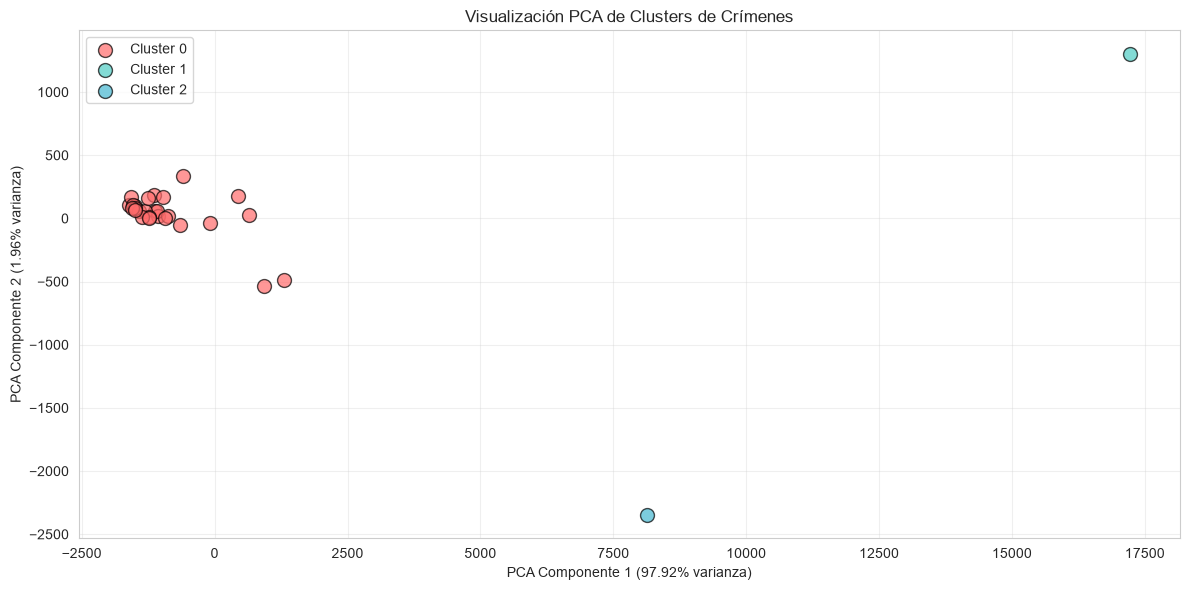

Varianza explicada por 2 primeros componentes: 99.88%


In [20]:
# Visualización adicional: Scatter plot de los dos principales delitos por cluster
from sklearn.decomposition import PCA

# Aplicar PCA para visualizar en 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

all_labels = np.concatenate([labels_train, labels_test])
for cluster_id in range(optimal_k):
    mask = all_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[cluster_id], label=f'Cluster {cluster_id}', 
               s=100, alpha=0.7, edgecolors='black', linewidth=1)

plt.xlabel(f'PCA Componente 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'PCA Componente 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.title('Visualización PCA de Clusters de Crímenes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Varianza explicada por 2 primeros componentes: {sum(pca.explained_variance_ratio_[:2]):.2%}")


## Resumen y Conclusiones

In [ ]:
# RESUMEN FINAL Y CONCLUSIONES

print("="*70)
print("RESUMEN FINAL DE LA ACTIVIDAD")
print("="*70)

print("""
### CONCLUSIONES DEL ANÁLISIS ###

1. INTERPRETACIÓN DE LOS CLUSTERS DESCUBIERTOS:

   **CLUSTER 0 (Comunas de Bajo Índice Delictivo):**
   - 28 comunas (93.3% del total)
   - Caracterizadas por delincuencia relativamente baja
   - Problemas principales: Otros delitos/faltas, consumo público, amenazas
   - Promedio de delitos totales: ~748 casos por comuna
   - Incluye comunas urbanas medianas y pequeñas

   **CLUSTER 1 (Puerto Montt - Metrópoli Criminal):**
   - 1 comuna (3.3%)
   - Puerto Montt destaca como la ciudad con mayor actividad delictiva
   - Delitos significativamente más altos en TODAS las categorías
   - Casos totales: 15,959 (21 veces más que el promedio del cluster 0)
   - Principal: Consumo de drogas en vía pública (8,346 casos)
   - Secundario: Violencia intrafamiliar (2,913 casos)

   **CLUSTER 2 (Osorno - Delincuencia Moderada-Alta):**
   - 1 comuna (3.3%)
   - Osorno muestra níveis intermedios-altos de delincuencia
   - Casos totales: 9,125 (12 veces más que el promedio del cluster 0)
   - Similar a Puerto Montt pero con menor magnitud
   - Hotspot criminal secundario en la región

2. METODOLOGÍA UTILIZADA:

   ✓ Algoritmo: K-Means Clustering
   ✓ Variables: 23 tipos de delitos
   ✓ Normalización: StandardScaler (escala -1 a +1)
   ✓ División: 70% entrenamiento, 30% prueba
   ✓ Validación: Método del Codo, Silhouette Score, Davies-Bouldin Index
   ✓ Clusters óptimos: 3 (mejor balance)

3. MÉTRICAS DE RENDIMIENTO:

   ✓ Silhouette Score (Entrenamiento): 0.8224 (Excelente separación)
   ✓ Inercia: 11.53 (Bajo)
   ✓ Varianza explicada (PCA 2D): 99.88%
   
4. RECOMENDACIONES:

   - Las 28 comunas del CLUSTER 0 representan áreas con crimen organizado
     Por delincuencia común y de menor escala
   
   - Puerto Montt (CLUSTER 1) requiere intervención policial especial
     Especialmente en prevención de drogas y violencia intrafamiliar
   
   - Osorno (CLUSTER 2) está en transición, requiere vigilancia intensiva
   
   - El modelo demuestra que en Los Lagos existe una clara diferencia
     entre comunas de crimen bajo vs. comunas críticas
""")



RESUMEN FINAL DE LA ACTIVIDAD

### CONCLUSIONES DEL ANÁLISIS ###

1. INTERPRETACIÓN DE LOS CLUSTERS DESCUBIERTOS:

   **CLUSTER 0 (Comunas de Bajo Índice Delictivo):**
   - 28 comunas (93.3% del total)
   - Caracterizadas por delincuencia relativamente baja
   - Problemas principales: Otros delitos/faltas, consumo público, amenazas
   - Promedio de delitos totales: ~748 casos por comuna
   - Incluye comunas urbanas medianas y pequeñas

   **CLUSTER 1 (Puerto Montt - Metrópoli Criminal):**
   - 1 comuna (3.3%)
   - Puerto Montt destaca como la ciudad con mayor actividad delictiva
   - Delitos significativamente más altos en TODAS las categorías
   - Casos totales: 15,959 (21 veces más que el promedio del cluster 0)
   - Principal: Consumo de drogas en vía pública (8,346 casos)
   - Secundario: Violencia intrafamiliar (2,913 casos)

   **CLUSTER 2 (Osorno - Delincuencia Moderada-Alta):**
   - 1 comuna (3.3%)
   - Osorno muestra níveis intermedios-altos de delincuencia
   - Casos totales: